In [24]:
using CairoMakie, DataFramesMeta, PrettyTables, Symbolics, Groebner, Latexify
CairoMakie.activate!()
Makie.inline!(true)

[ Info: Precompiling SymbolicsGroebnerExt [3dcf9498-7507-52a5-97c9-e871bd48cf7f] (caches not reused: 1 for different dependency version already loaded)
Precompiling packages...
   1553.1 ms  ✓ Groebner → GroebnerDynamicPolynomialsExt
   2913.9 ms  ✓ Symbolics → SymbolicsGroebnerExt
  2 dependencies successfully precompiled in 4 seconds. 120 already precompiled.


true

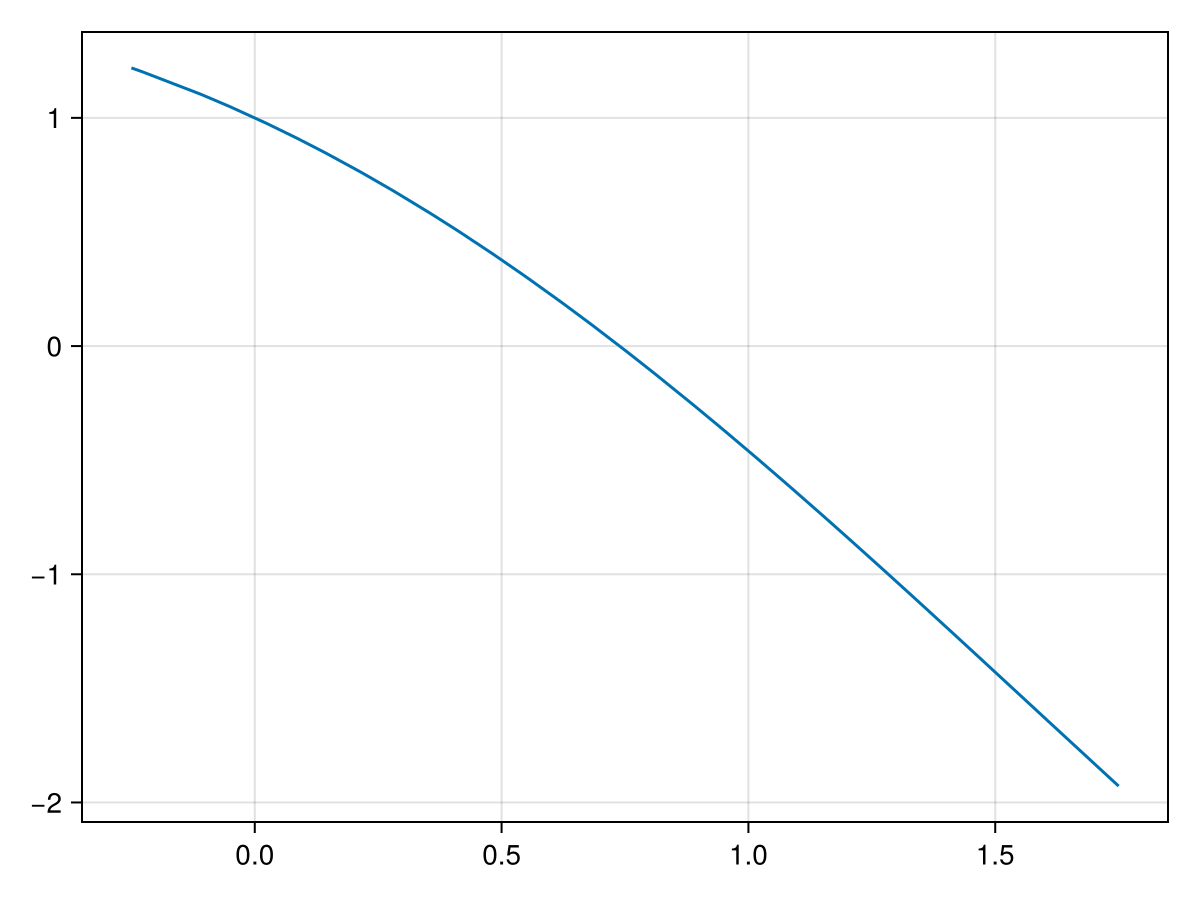

In [ ]:
lines(-0.25..1.75,x->cos(x)-x)

In [ ]:
function iterate(f::Function, x0::Real; tol=1e-8, maxiter=100)
  x = Vector{typeof(x0)}()
  push!(x, x0)
  for i = 2:maxiter
    push!(x, f(x[end]))
    abs(x[end-1] - x[end]) < tol && return x
  end
  @show x
  error("Maximum iterations reached")
  x
end

iterate (generic function with 1 method)

In [ ]:
function secant(f::Function, x0::Real, x1::Real; tol=1e-8, maxiter=100)
  x = Vector{typeof(x0)}()
  push!(x, x0, x1)
  for i = 3:maxiter
    push!(x, x[end] - f(x[end]) * (x[end] - x[end-1]) / (f(x[end]) - f(x[end-1])))
    abs(x[end-1] - x[end]) < tol && return x
  end
  @show x
  error("Maximum iterations reached.")
end

secant (generic function with 3 methods)

In [ ]:
s1 = secant(x->cos(x)-x,1.5,1.0)

7-element Vector{Float64}:
 1.5
 1.0
 0.7629361390275307
 0.7402643775006839
 0.739091262461842
 0.7390851348101232
 0.7390851332151628

In [ ]:
@chain DataFrame(x = s1) begin
  @transform(:f = cos.(:x) .- :x)
  pretty_table(_; backend = :latex)
end

\begin{tabular}{|r|r|}
  \hline
  \textbf{x} & \textbf{f} \\
  \textit{Float64} & \textit{Float64} \\
  \hline
  1.5 & -1.42926 \\
  1.0 & -0.459698 \\
  0.762936 & -0.040126 \\
  0.740264 & -0.00197411 \\
  0.739091 & -1.0258e-5 \\
  0.739085 & -2.66935e-9 \\
  0.739085 & -3.55271e-15 \\
  \hline
\end{tabular}


In [ ]:
s1 = secant(x->cos(x)-x,big(1.5),big(1.0), tol = 1e-50)

11-element Vector{BigFloat}:
 1.5
 1.0
 0.7629361390275306176066985751579842228200481907958133044988437258919441360341046
 0.7402643775006838581361201098767559891937310704735837623002779206349450237389184
 0.7390912624618420525681085740903948946679124479429211649860757024096021997251313
 0.7390851348101231179835732458877036412972149154041166962188436561893989493471489
 0.7390851332151628002239159595150996564555995361995299972499833472695119464984784
 0.7390851332151606416553128478706222102291472782652773904548503721442794045556822
 0.739085133215160641655312087673873404013774086608121126978868221560210843256501
 0.7390851332151606416553120876738734040134117589007574649656806358341033693260354
 0.739085133215160641655312087673873404013411758900757464965680635773284654883551

In [ ]:
eps1 = abs.(s1 .- s1[end])

11-element Vector{BigFloat}:
 0.760914866784839358344687912326126595986588241099242535034319364226715345116449
 0.260914866784839358344687912326126595986588241099242535034319364226715345116449
 0.02385100581236997595138648748411081880663643189505583953316309011865948115055362
 0.001179244285523216480808022202882585180319311572826297334597284861660368855367368
 6.12924668141091279648641652149065450068904216370002039506663631754484158024011e-6
 1.594962476328261158213830237283803156503359231253163020416114294463597838847592e-9
 2.158568603871841226252442187777298772532284302711496227291614927379647193530476e-15
 7.601967488062157355193645199254891697363709947496721311753516368623530356592161e-25
 3.623277073636620131875857869261883729499470372437689219152258696670433109911743e-40
 6.081871444248435726863018424879509143090746328377477139381328588635107832029744e-65
 0.0

In [ ]:
order(eps::Vector{<:Real}) = log.(eps[3:end]./eps[2:end-1])./log.(eps[2:end-1]./eps[1:end-2])

order (generic function with 1 method)

In [ ]:
order(eps1)

9-element Vector{BigFloat}:
  2.235174012672081862545281019664130282714335784753509466091444269259097736539266
  1.256893948848047168617056468635282038569182157381446264036496496345244420181094
  1.749132074491883947464767328167123783737863047605252656522651026128607634373536
  1.569329236026720442859981151817641813846843663019767965555665406853578320069322
  1.637139960434372346429153683164523722370347209642168429549139148619431861386113
  1.61082108714101208950246220207872274388653102007269198142722136758720622698172
  1.620801408623811065041393317139687992514103453402528147740822518610050120169619
  1.616978733285457934494223551833462218986835402538429694906637979979407109018192
 Inf

In [ ]:
@chain DataFrame(n=0:length(s1)-1, x=s1, f = cos.(s1) - s1) begin
  pretty_table( formatters = [fmt__printf("%25.20f",[2]),fmt__printf("%15.12e",[3])], backend = :latex)
end

\begin{tabular}{|r|r|r|}
  \hline
  \textbf{n} & \textbf{x} & \textbf{f} \\
  \textit{Int64} & \textit{BigFloat} & \textit{BigFloat} \\
  \hline
  0 &    1.50000000000000000000 & -1.429262798332e+00 \\
  1 &    1.00000000000000000000 & -4.596976941319e-01 \\
  2 &    0.76293613902753061761 & -4.012601889379e-02 \\
  3 &    0.74026437750068385814 & -1.974111129638e-03 \\
  4 &    0.73909126246184205257 & -1.025799485867e-05 \\
  5 &    0.73908513481012311798 & -2.669348387419e-09 \\
  6 &    0.73908513321516280022 & -3.612606381257e-15 \\
  7 &    0.73908513321516064166 & -1.272274423348e-24 \\
  8 &    0.73908513321516064166 & -6.063960095502e-40 \\
  9 &    0.73908513321516064166 & -1.017869320904e-64 \\
  10 &    0.73908513321516064166 & -8.636168555094e-78 \\
  \hline
\end{tabular}


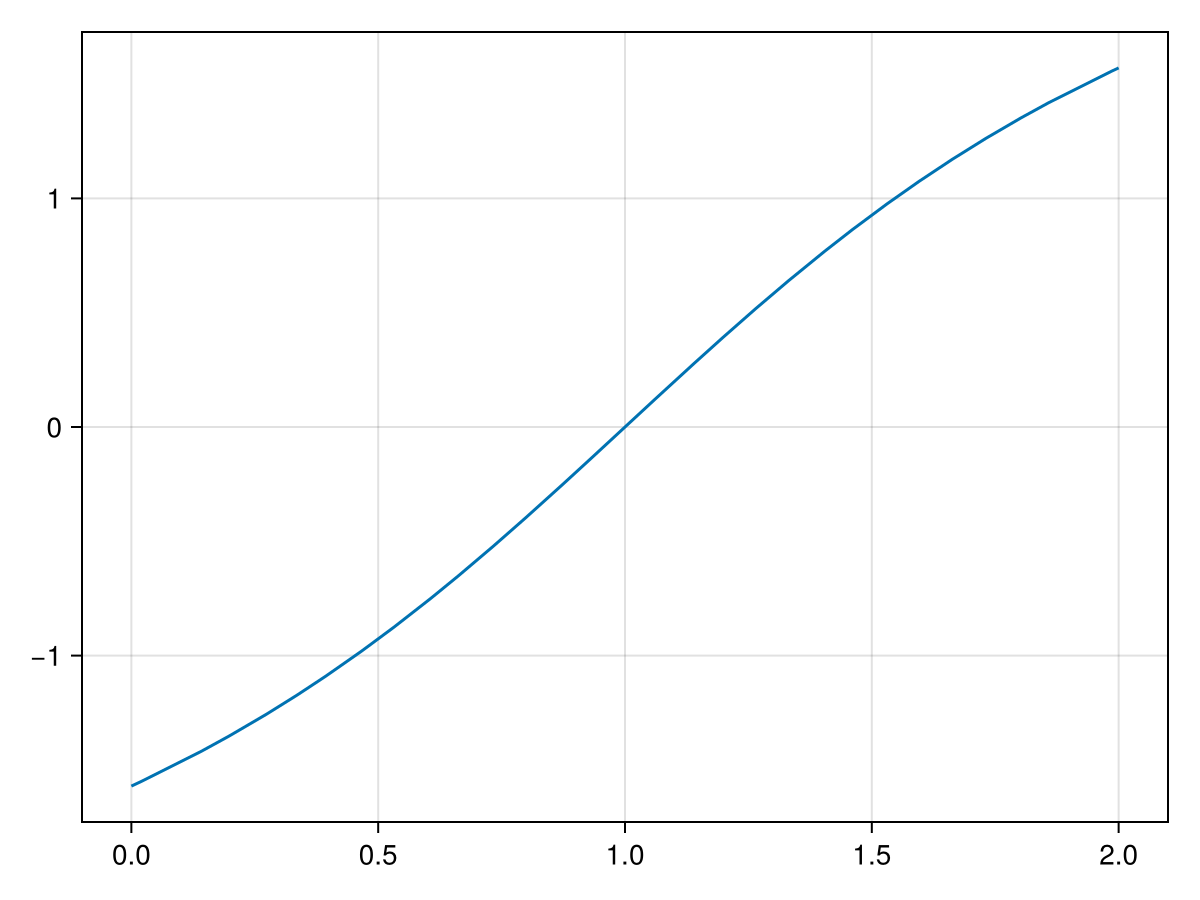

In [ ]:
lines(0..2, x-> 2*atan(x-1))

In [1]:
(-3//2*3 + 1//3*2)/(2*5)

-23//60

In [2]:
(1//3+3//2)//5

11//30

In [32]:
q(x) = 1 - 23//30*(x-3) +11//30*(x-3)^2

q (generic function with 1 method)

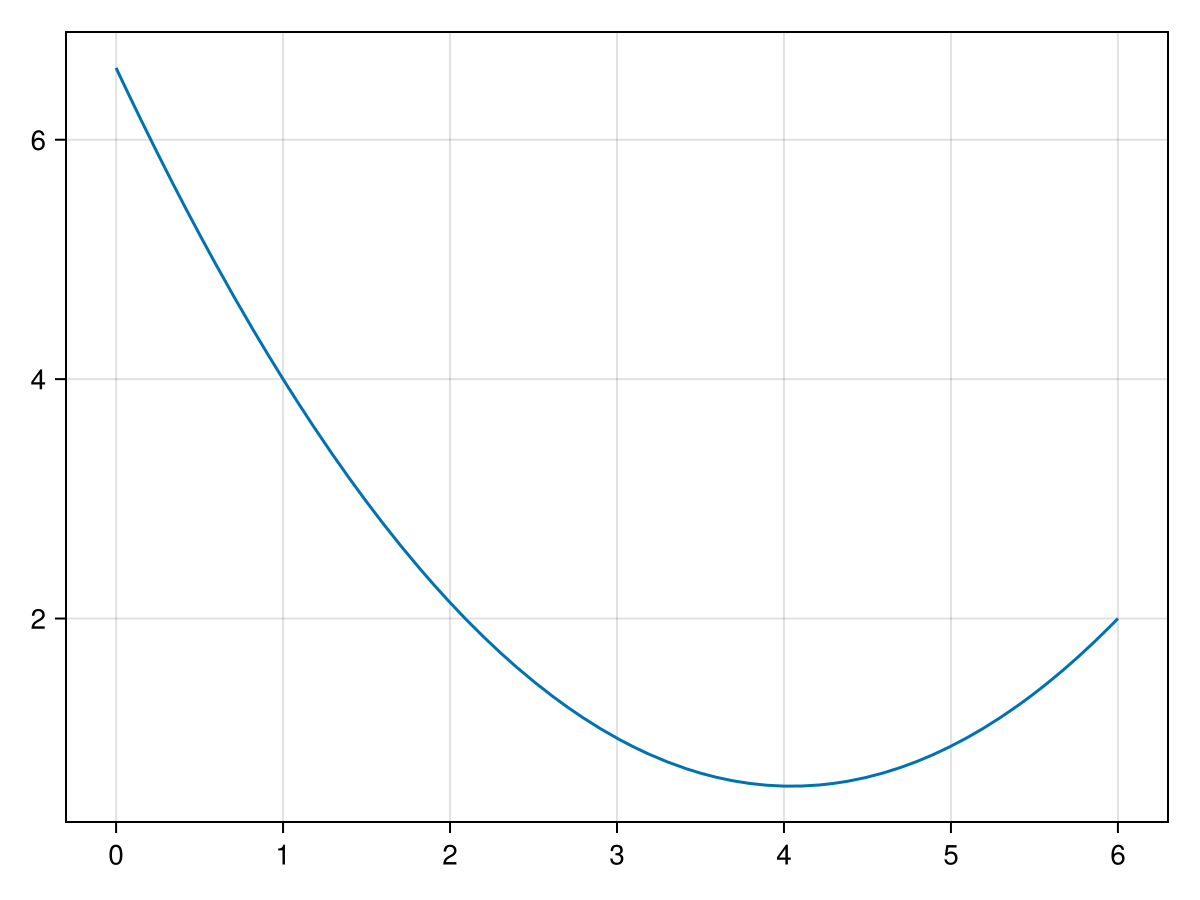

In [33]:
lines(0..6,q)

In [15]:
@variables x a[0:2]

2-element Vector{Any}:
 x
  a[0:2]

In [16]:
q(x) = a[0] + a[1]*(x-3)+ a[2]*(x-3)^2

q (generic function with 1 method)

In [17]:
q(x)

a[0] + a[1]*(-3 + x) + a[2]*((-3 + x)^2)

In [26]:
sol = Symbolics.symbolic_solve([
  q(1) ~ 4, 
  q(3) ~ 1,
  q(6) ~ 2
],[a[0],a[1],a[2]])

1-element Vector{Any}:
 Dict{Num, Any}(a[0] => 1, a[1] => (-23//30), a[2] => (11//30))

In [29]:
substitute(q(x), sol[1])

1 - (23//30)*(-3 + x) + (11//30)*((-3 + x)^2)

In [30]:
q1(x) = 1 - 23//30*(x-3) +11//30*(x-3)^2

q1 (generic function with 1 method)

In [31]:
q1(1), q1(6)

(4//1, 2//1)

## Muller's method

Solve $f(x) = \cos x -x $

In [34]:
f(x) = cos(x) -x

f (generic function with 1 method)

In [ ]:
h₁, h₂ x₁ x₀ x₂

In [35]:
function muller(f::Function, x0::Real, x1::Real, x2::Real; tol = 1e-8, maxiter= 20)
  h1 = x1 -x0
  h2 = x2-x1
  δ1 = (f(x1)-f(x0))/h1
  δ2 = (f(x2)-f(x1))/h2
  a0 = f(x1)
  a1 = (δ1*h2+δ2*h1)/(h1+h2)
  a2 = (δ2-δ1)/(h1+h2)
  (a0, a1,a2)
end

muller (generic function with 1 method)

In [40]:
m = muller(x->cos(x)-x, 0,1,2)

(-0.45969769413186023, -1.7080734182735713, -0.24837572414171105)

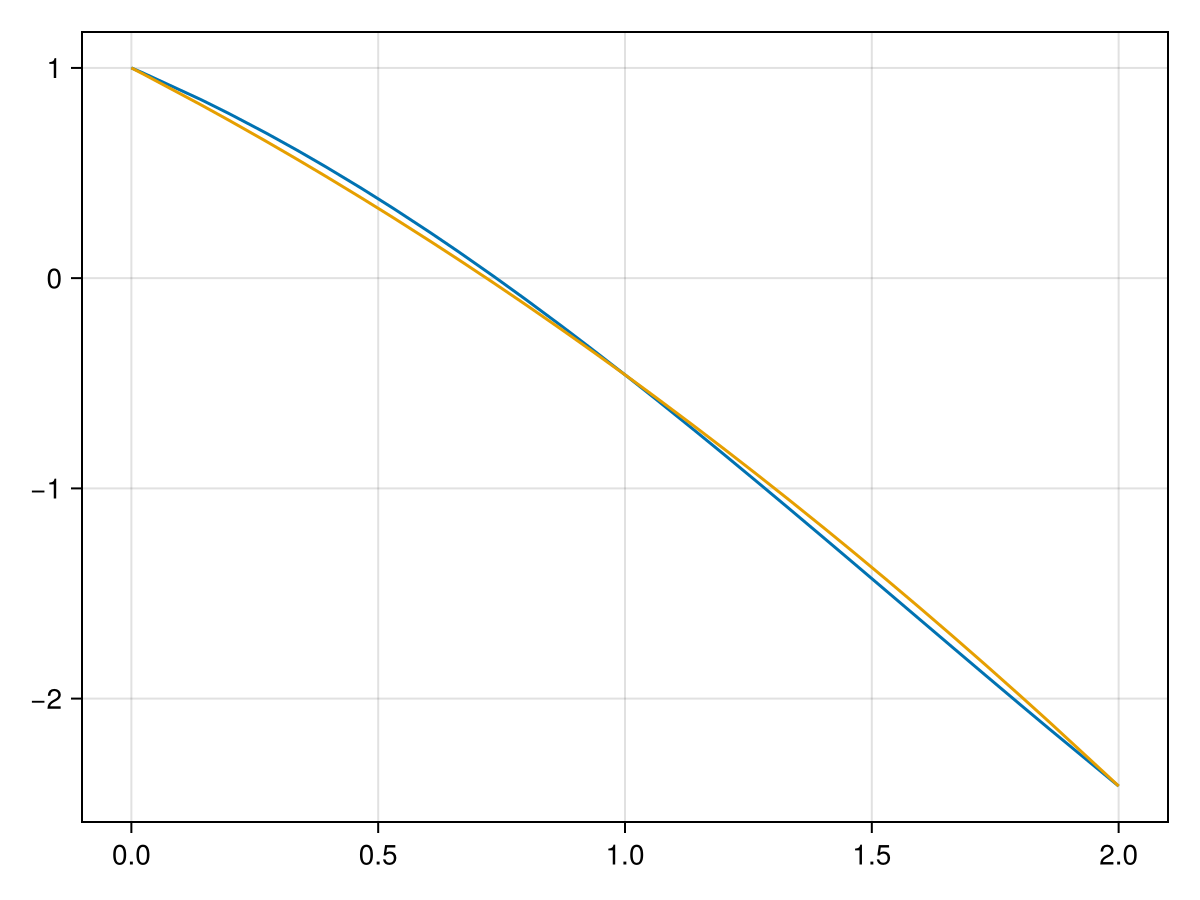

In [51]:
fig, ax = lines(0..2,x->cos(x)-x)
lines!(ax,0..2,x->m[1]+m[2]*(x-1)+m[3]*(x-1)^2)
fig

In [50]:
1 + (-m[2]-sqrt(m[2]^2-4m[1]*m[3]))/2m[3]

0.719420084660078

In [56]:
1 + 2m[1]/(-m[2]+sqrt(m[2]^2-4m[1]*m[3]))

0.7194200846600776